# **Task 5 — Model Evaluation & Hyperparameter Tunin**

---


**Author:** Shoaib Muhammad  
**Internship:** Neurofive Solutions — Machine Learning Track  
**Task:** Model Evaluation & Tuning: Beyond Accuracy  
**Dataset:** Titanic Dataset  
**Model:** Logistic Regression

---

## **Objective**

The objective of this task is to evaluate the Titanic classification model using metrics beyond accuracy and improve the model using hyperparameter tuning.

In this task, Precision, Recall, and F1-score are calculated using `classification_report`. GridSearchCV is then used to systematically search for better Logistic Regression hyperparameters. Finally, the original and tuned models are compared using a before-and-after performance table.

# **Import Libraries**

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# **Load Dataset**

In [3]:
# Load the Titanic dataset

df = pd.read_csv("train.csv")

# Display the first five rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Inspection

## Dataset Inspection

The Titanic dataset is inspected before preparing it for model training. This helps confirm the structure of the dataset and identify any missing values that need to be handled.

In [4]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **Handle Missing Values**

In [5]:
# Fill missing Age values with the median

df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because of its large number of missing values

df = df.drop(columns=["Cabin"])

# Check remaining missing values

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Select Features and Target

## Features and Target

The target variable is `Survived`, which represents whether a passenger survived.

The selected features are passenger class, gender, age, family information, fare, and embarkation port.

In [10]:
# Select input features

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]

# Select target variable

y = df["Survived"]

print("Features:", features)
print("Target: Survived")

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target: Survived


# Train-Test Split

## Train-Test Split

The dataset is divided into training and testing sets.

The training data is used to train the model, while the test data is kept separate for evaluating performance on unseen data.

An 80/20 split is used, with `random_state=42` to make the results reproducible.

In [12]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


# Define Categorical and Numerical Feature

In [13]:
# Define categorical features

categorical_features = [
    "Sex",
    "Embarked"
]

# Define numerical features

numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Sex', 'Embarked']
Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


# Create Preprocessor

In [16]:
# Create a preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Create Original Model

## Original Logistic Regression Model

The original Logistic Regression model from the previous task is used as the baseline model.

Its performance will be compared with the tuned model to determine whether hyperparameter tuning improves the results.

In [17]:
# Create the original Logistic Regression pipeline

original_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Train the original model

original_model.fit(X_train, y_train)

print("Original model trained successfully!")

Original model trained successfully!


# Original Predictions

In [18]:
# Make predictions using the original model

y_pred_original = original_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_original[:10])

First 10 predictions:
[0 0 0 0 1 0 1 0 0 0]


# Original Accuracy

In [19]:
# Calculate original model accuracy

original_accuracy = accuracy_score(
    y_test,
    y_pred_original
)

print(f"Original Accuracy: {original_accuracy:.2%}")

Original Accuracy: 80.45%


# Precision, Recall & F1-Score

## Classification Report

Accuracy alone does not provide the complete picture of a classification model's performance.

Therefore, Precision, Recall, and F1-score are calculated using Scikit-learn's `classification_report`.

- **Precision:** Of the passengers predicted as survivors, how many actually survived?
- **Recall:** Of the passengers who actually survived, how many were correctly identified?
- **F1-score:** A combined measure of Precision and Recall.

In [20]:
# Generate classification report for the original model

print("Original Model Classification Report")
print("--------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_original,
        target_names=["Did Not Survive", "Survived"]
    )
)

Original Model Classification Report
--------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



# Why Accuracy Can Be Misleading

## Why Accuracy Alone Can Be Misleading

Accuracy tells us the percentage of all predictions that were correct, but it does not show how the model performs for each class.

This can be misleading when a dataset is imbalanced. For example, if one class contains most of the observations, a model could achieve high accuracy by mostly predicting the majority class while performing poorly on the smaller class.

Precision, Recall, and F1-score provide additional information about how well the model handles each class.

# Hyperparameter Tuning

## Hyperparameter Tuning with GridSearchCV

Hyperparameter tuning is used to systematically search for model settings that may improve performance.

In this task, GridSearchCV is used to test different values of the Logistic Regression hyperparameters `C` and `solver`.

Instead of manually guessing the settings, GridSearchCV evaluates different combinations using cross-validation and identifies the best combination according to the selected scoring metric.

# Define Parameter Grid

In [21]:
# Define hyperparameters to tune

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

print("Hyperparameters selected for tuning:")
print("C:", param_grid["classifier__C"])
print("Solver:", param_grid["classifier__solver"])

Hyperparameters selected for tuning:
C: [0.01, 0.1, 1, 10, 100]
Solver: ['liblinear', 'lbfgs']


# GridSearchCV

In [22]:
# Create GridSearchCV

grid_search = GridSearchCV(
    estimator=original_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Run the grid search

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Hyperparameter tuning completed!


# Best Parameters

In [23]:
# Display the best hyperparameters

print("Best Hyperparameters:")
print(grid_search.best_params_)

Best Hyperparameters:
{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}


# Best Cross-Validation Score

In [24]:
# Display the best cross-validation score

print(
    f"Best Cross-Validation Accuracy: "
    f"{grid_search.best_score_:.2%}"
)

Best Cross-Validation Accuracy: 79.78%


# Tuned Model Predictions

## Tuned Model Evaluation

The best model identified by GridSearchCV is now evaluated on the test dataset. The test dataset remains unseen during training and hyperparameter selection, allowing us to compare the tuned model fairly with the original model.

In [25]:
# Generate predictions using the tuned model

y_pred_tuned = grid_search.predict(X_test)

print("Tuned model predictions generated successfully!")

Tuned model predictions generated successfully!


# Tuned Accuracy

In [26]:
# Calculate tuned model accuracy

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

print(f"Tuned Accuracy: {tuned_accuracy:.2%}")

Tuned Accuracy: 79.33%


# Tuned Classification Report

In [27]:
# Generate classification report for the tuned model

print("Tuned Model Classification Report")
print("----------------------------------")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Did Not Survive", "Survived"]
    )
)

Tuned Model Classification Report
----------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.88      0.84       110
       Survived       0.78      0.65      0.71        69

       accuracy                           0.79       179
      macro avg       0.79      0.77      0.77       179
   weighted avg       0.79      0.79      0.79       179



# Before vs After Comparison

## Before vs After Model Comparison

The original and tuned Logistic Regression models are compared using accuracy. This comparison helps determine whether hyperparameter tuning improved the model's performance.

In [28]:
# Create a before-and-after comparison table

comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        original_accuracy,
        tuned_accuracy
    ]
})

# Convert accuracy to percentage

comparison["Accuracy"] = (
    comparison["Accuracy"] * 100
).round(2)

comparison

,Model,Accuracy
0,Original Logistic Regression,80.45
1,Tuned Logistic Regression,79.33


# Compare Precision, Recall and F1

In [29]:
# Generate classification reports as dictionaries

original_report = classification_report(
    y_test,
    y_pred_original,
    output_dict=True
)

tuned_report = classification_report(
    y_test,
    y_pred_tuned,
    output_dict=True
)

# Create comparison of weighted-average metrics

metrics_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Original Model": [
        original_accuracy,
        original_report["weighted avg"]["precision"],
        original_report["weighted avg"]["recall"],
        original_report["weighted avg"]["f1-score"]
    ],
    "Tuned Model": [
        tuned_accuracy,
        tuned_report["weighted avg"]["precision"],
        tuned_report["weighted avg"]["recall"],
        tuned_report["weighted avg"]["f1-score"]
    ]
})

metrics_comparison

,Metric,Original Model,Tuned Model
0,Accuracy,0.804469,0.793296
1,Precision,0.803436,0.791711
2,Recall,0.804469,0.793296
3,F1-Score,0.800657,0.789266


# Confusion Matrix for Tuned Model

## Confusion Matrix — Tuned Model

The confusion matrix shows the correct and incorrect predictions made by the tuned Logistic Regression model.

In [30]:
# Calculate confusion matrix for the tuned model

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

print("Tuned Model Confusion Matrix:")
print(cm_tuned)

Tuned Model Confusion Matrix:
[[97 13]
 [24 45]]


# Visualize Confusion Matrix

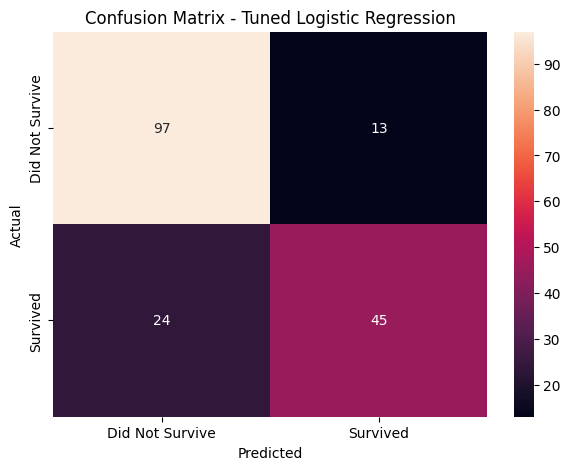

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Hyperparameter Tuning Result

## 🔧 Hyperparameter Tuning Result

GridSearchCV tested multiple combinations of the Logistic Regression hyperparameters `C` and `solver`.

The best combination was selected based on cross-validation accuracy. The tuned model was then evaluated on the same test dataset used to evaluate the original model.

Hyperparameter tuning does not always guarantee a large improvement. Its purpose is to systematically search for better settings rather than relying on manual guessing.

In [32]:
# Display the best parameters and final results

print("Best Parameters:")
print(grid_search.best_params_)

print("\nOriginal Accuracy:")
print(f"{original_accuracy:.2%}")

print("\nTuned Accuracy:")
print(f"{tuned_accuracy:.2%}")

Best Parameters:
{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}

Original Accuracy:
80.45%

Tuned Accuracy:
79.33%


# Final Conclusion

----

In this task, I evaluated the Titanic Logistic Regression model using Accuracy, Precision, Recall, and F1-score instead of relying on accuracy alone. GridSearchCV was used to systematically tune the `C` and `solver` hyperparameters of the Logistic Regression model. The original and tuned models were compared on the same test dataset to determine whether tuning improved performance. This task helped me understand why multiple evaluation metrics are important and how hyperparameter tuning can be used to improve a machine learning model systematically.